In [146]:
import os
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers, Model
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications import MobileNetV3Large
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input as mobilenet_preprocess
import json

In [147]:
IMG_HEIGHT = 256
IMG_WIDTH  = 256
MOBILE_HEIGHT = 224
MOBILE_WIDTH  = 224 
BATCH_SIZE = 8

data_dir = "/kaggle/input/datasets/aryashah2k/breast-ultrasound-images-dataset/Dataset_BUSI_with_GT"


In [117]:

out_img_dir  = "/kaggle/working/images"
out_mask_dir = "/kaggle/working/masks"
os.makedirs(out_img_dir, exist_ok=True)
os.makedirs(out_mask_dir, exist_ok=True)

index = 1
for class_name in ["benign", "malignant"]:
    class_path = os.path.join(data_dir, class_name)
    for file in os.listdir(class_path):
        if "_mask" in file:
            continue
        img_path  = os.path.join(class_path, file)
        img       = cv2.imread(img_path, 0)
        img       = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))
        new_name  = f"{index:03d}.png"

        mask_path = img_path.replace(".png", "_mask.png")
        mask      = cv2.imread(mask_path, 0)
        mask      = cv2.resize(mask, (IMG_WIDTH, IMG_HEIGHT), interpolation=cv2.INTER_NEAREST)

        cv2.imwrite(os.path.join(out_img_dir, new_name), img)
        cv2.imwrite(os.path.join(out_mask_dir, new_name.replace(".png", "_mask.png")), mask)
        index += 1
print("Xong!")


Xong!


In [118]:

image_dir  = "/kaggle/working/images"
mask_dir   = "/kaggle/working/masks"
img_paths  = []
mask_paths = []

for file in sorted(os.listdir(image_dir)):
    img_paths.append(os.path.join(image_dir, file))
    mask_name = file.replace(".png", "_mask.png")
    mask_paths.append(os.path.join(mask_dir, mask_name))

In [148]:
train_imgs, test_imgs, train_masks, test_masks = train_test_split(
    img_paths, mask_paths, test_size=0.15, random_state=42
)
train_imgs, val_imgs, train_masks, val_masks = train_test_split(
    train_imgs, train_masks, test_size=0.15, random_state=42
)
total_imgs  = len(img_paths)
total_masks = len(mask_paths)
print("=" * 45)
print(f"  Tổng số ảnh  : {total_imgs}")
print(f"  Tổng số mask : {total_masks}")
print("-" * 45)
print(f"  Train — ảnh: {len(train_imgs):4d} | mask: {len(train_masks):4d}")
print(f"  Val   — ảnh: {len(val_imgs):4d} | mask: {len(val_masks):4d}")
print(f"  Test  — ảnh: {len(test_imgs):4d} | mask: {len(test_masks):4d}")
print("=" * 45)

  Tổng số ảnh  : 647
  Tổng số mask : 647
---------------------------------------------
  Train — ảnh:  466 | mask:  466
  Val   — ảnh:   83 | mask:   83
  Test  — ảnh:   98 | mask:   98


In [149]:
def read_mask(path):
    """Đọc mask — dùng chung cho cả 3 model."""
    if isinstance(path, bytes):
        path = path.decode()
    mask = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    mask = cv2.resize(mask, (IMG_WIDTH, IMG_HEIGHT), interpolation=cv2.INTER_NEAREST)
    mask = (mask > 0).astype(np.float32)
    mask = np.expand_dims(mask, axis=-1)
    return mask

def read_image_unet(path):
    if isinstance(path, bytes):
        path = path.decode()
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))
    img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    img = img.astype(np.float32) / 255.0
    return img

def read_image_resnet(path):
    if isinstance(path, bytes):
        path = path.decode()
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))
    img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    img = img.astype(np.float32)
    img = resnet_preprocess(img)
    return img

def read_image_mobilenet(path):
    if isinstance(path, bytes):
        path = path.decode()
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (MOBILE_WIDTH, MOBILE_HEIGHT))  # ← 224×224
    img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    img = img.astype(np.float32)
    img = mobilenet_preprocess(img)
    return img

def read_mask_mobilenet(path):
    if isinstance(path, bytes):
        path = path.decode()
    mask = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    mask = cv2.resize(mask, (MOBILE_WIDTH, MOBILE_HEIGHT),
                      interpolation=cv2.INTER_NEAREST)
    mask = (mask > 0).astype(np.float32)
    mask = np.expand_dims(mask, axis=-1)
    return mask

In [150]:
def augment(image, mask):
    if tf.random.uniform(()) > 0.5:
        image = tf.image.flip_left_right(image)
        mask  = tf.image.flip_left_right(mask)
    if tf.random.uniform(()) > 0.5:
        image = tf.image.flip_up_down(image)
        mask  = tf.image.flip_up_down(mask)
    if tf.random.uniform(()) > 0.5:
        k     = tf.random.uniform(shape=[], minval=0, maxval=4, dtype=tf.int32)
        image = tf.image.rot90(image, k)
        mask  = tf.image.rot90(mask, k)
    return image, mask

In [151]:
def load_all_images(img_paths, mask_paths, read_image_fn,
                    read_mask_fn=read_mask):  # ← thêm tham số này
    print(f"  Đang load {len(img_paths)} ảnh vào RAM...", end=" ")
    X = np.array([read_image_fn(p)  for p in img_paths],  dtype=np.float32)
    y = np.array([read_mask_fn(p)   for p in mask_paths], dtype=np.float32)
    print("xong!")
    return X, y

In [152]:
def make_dataset(X, y, augment_data=False, shuffle=False, batch_size=BATCH_SIZE):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(X))
    if augment_data:
        ds = ds.map(augment, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

In [153]:
def dice_coefficient(y_true, y_pred, smooth=1e-6):
    y_true_f    = tf.keras.backend.flatten(y_true)
    y_pred_f    = tf.keras.backend.flatten(y_pred)
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth)

def iou_score(y_true, y_pred, smooth=1e-6):
    y_true_f    = tf.keras.backend.flatten(y_true)
    y_pred_f    = tf.keras.backend.flatten(y_pred)
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    total        = tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f)
    union        = total - intersection
    return (intersection + smooth) / (union + smooth)

def binary_dice_coefficient(y_true, y_pred, threshold=0.5, smooth=1e-6):
    y_pred_bin = tf.cast(y_pred > threshold, tf.float32)
    return dice_coefficient(y_true, y_pred_bin, smooth=smooth)


def binary_iou_score(y_true, y_pred, threshold=0.5, smooth=1e-6):
    y_pred_bin = tf.cast(y_pred > threshold, tf.float32)
    return iou_score(y_true, y_pred_bin, smooth=smooth)

def bce_dice_loss(y_true, y_pred):
    bce = tf.reduce_mean(tf.keras.losses.binary_crossentropy(y_true, y_pred))
    dice_loss = 1.0 - dice_coefficient(y_true, y_pred)
    return 0.3 * bce + 0.7 * dice_loss


In [154]:
def conv_block(inputs, num_filters):
    x = layers.Conv2D(num_filters, 3, padding="same")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Conv2D(num_filters, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    return x

def decoder_block(inputs, skip, num_filters):
    x = layers.UpSampling2D(size=(2, 2), interpolation="bilinear")(inputs)
    if skip is not None:
        # Crop nếu kích thước lệch
        x = layers.Concatenate()([x, skip])
    x = conv_block(x, num_filters)
    return x

# **BUILD UNET**

In [93]:
def build_unet(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)):
    inputs = layers.Input(shape=input_shape)

    # Encoder 
    c1 = conv_block(inputs, 64);  p1 = layers.MaxPooling2D(name="enc_pool1")(c1)
    c2 = conv_block(p1,     128); p2 = layers.MaxPooling2D(name="enc_pool2")(c2)
    c3 = conv_block(p2,     256); p3 = layers.MaxPooling2D(name="enc_pool3")(c3)
    c4 = conv_block(p3,     512); p4 = layers.MaxPooling2D(name="enc_pool4")(c4)

    # Bottleneck
    c5 = conv_block(p4, 1024)

    # Decoder 
    d6 = decoder_block(c5, c4, 512)
    d7 = decoder_block(d6, c3, 256)
    d8 = decoder_block(d7, c2, 128)
    d9 = decoder_block(d8, c1,  64)

    outputs = layers.Conv2D(1, 1, activation="sigmoid")(d9)
    return Model(inputs, outputs, name="UNet")

# **BUILD RESNET-UNET**

In [155]:
def build_resnet_unet(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)):
    inputs    = layers.Input(shape=input_shape)
    base      = ResNet50(weights="imagenet", include_top=False, input_tensor=inputs)

    s1 = base.get_layer("conv1_relu").output          
    s2 = base.get_layer("conv2_block3_out").output    
    s3 = base.get_layer("conv3_block4_out").output    
    s4 = base.get_layer("conv4_block6_out").output    
    bn = base.get_layer("conv5_block3_out").output    

    # Decoder
    d1 = decoder_block(bn, s4, 512)   
    d2 = decoder_block(d1, s3, 256)   
    d3 = decoder_block(d2, s2, 128)   
    d4 = decoder_block(d3, s1,  64)   
    d5 = decoder_block(d4, None, 32)  

    outputs = layers.Conv2D(1, 1, activation="sigmoid")(d5)
    return Model(inputs, outputs, name="ResNet50_UNet"), base

# **BUILD MOBILENET-UNET**

In [156]:
def build_mobilenet_unet(input_shape=(MOBILE_HEIGHT, MOBILE_WIDTH, 3)):
    inputs = layers.Input(shape=input_shape)
    base = MobileNetV3Large(
        weights="imagenet",
        include_top=False,
        input_tensor=inputs,
        include_preprocessing=False,
    )

    s1 = base.get_layer("expanded_conv_add").output
    s2 = base.get_layer("expanded_conv_2_add").output
    s3 = base.get_layer("expanded_conv_5_add").output
    s4 = base.get_layer("expanded_conv_11_add").output
    bn = base.output

    d1 = decoder_block(bn, s4, 256)
    d2 = decoder_block(d1, s3, 128)
    d3 = decoder_block(d2, s2, 64)
    d4 = decoder_block(d3, s1, 32)
    d5 = decoder_block(d4, None, 16)

    outputs = layers.Conv2D(1, 1, activation="sigmoid")(d5)
    return Model(inputs, outputs, name="MobileNetV3_UNet"), base


In [157]:
def get_callbacks(model_name):
    return [
        ModelCheckpoint(
            f"/kaggle/working/{model_name}_best.keras",
            monitor="val_dice_coefficient", mode="max",
            save_best_only=True, verbose=1
        ),
        EarlyStopping(
            monitor="val_dice_coefficient", mode="max",
            patience=10, restore_best_weights=True, verbose=1
        ),
        ReduceLROnPlateau(
            monitor="val_dice_coefficient", mode="max",
            factor=0.5, patience=4, min_lr=1e-7, verbose=1
        ),
    ]

COMPILE_KWARGS = dict(
    optimizer=Adam(1e-4),
    loss=bce_dice_loss,
    metrics=[dice_coefficient, iou_score]
)


In [97]:
print("\n=== TRAINING U-Net ===")
print("Load dữ liệu U-Net:")
X_train_u, y_train_u = load_all_images(train_imgs, train_masks, read_image_unet)
X_val_u,   y_val_u   = load_all_images(val_imgs,   val_masks,   read_image_unet)
X_test_u,  y_test_u  = load_all_images(test_imgs,  test_masks,  read_image_unet)

ds_train_unet = make_dataset(X_train_u, y_train_u, augment_data=True,  shuffle=True)
ds_val_unet   = make_dataset(X_val_u,   y_val_u,   augment_data=False, shuffle=False)
ds_test_unet  = make_dataset(X_test_u,  y_test_u,  augment_data=False, shuffle=False)


=== TRAINING U-Net ===
Load dữ liệu U-Net:
  Đang load 466 ảnh vào RAM... xong!
  Đang load 83 ảnh vào RAM... xong!
  Đang load 98 ảnh vào RAM... xong!


In [98]:
unet_model = build_unet()
unet_model.compile(optimizer=Adam(1e-4), loss=bce_dice_loss, metrics=[dice_coefficient, iou_score])
unet_model.summary()

Model: "UNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_74 (Conv2D)  │ (None, 256, 256,  │      1,792 │ input_layer_8[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        256 │ conv2d_74[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_188      │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_75 (Conv2D)  │ (None, 256, 256,  │     36,928 │ activation_188[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        256 │ conv2d_75[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_189      │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_pool1           │ (None, 128, 128,  │          0 │ activation_189[0… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_76 (Conv2D)  │ (None, 128, 128,  │     73,856 │ enc_pool1[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ conv2d_76[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_190      │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_77 (Conv2D)  │ (None, 128, 128,  │    147,584 │ activation_190[0… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ conv2d_77[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_191      │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_pool2           │ (None, 64, 64,    │          0 │ activation_191[0… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_78 (Conv2D)  │ (None, 64, 64,    │    295,168 │ enc_pool2[0][0]   │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │      1,024 │ conv2d_78[0][0] 

 Total params: 31,402,497 (119.79 MB)

 Trainable params: 31,390,721 (119.75 MB)

 Non-trainable params: 11,776 (46.00 KB)

In [99]:
print(f"Train toàn bộ {len(unet_model.layers)} layers từ đầu")
history_unet = unet_model.fit(
    ds_train_unet,
    validation_data=ds_val_unet,
    epochs=40,
    callbacks=get_callbacks("unet")
)

Train toàn bộ 68 layers từ đầu
Epoch 1/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 818ms/step - dice_coefficient: 0.2298 - iou_score: 0.1328 - loss: 1.1470
Epoch 1: val_dice_coefficient improved from -inf to 0.18133, saving model to /kaggle/working/unet_best.keras
59/59 ━━━━━━━━━━━━━━━━━━━━ 79s 955ms/step - dice_coefficient: 0.2307 - iou_score: 0.1334 - loss: 1.1453 - val_dice_coefficient: 0.1813 - val_iou_score: 0.1004 - val_loss: 1.3948 - learning_rate: 1.0000e-04
Epoch 2/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 628ms/step - dice_coefficient: 0.3436 - iou_score: 0.2096 - loss: 0.9360
Epoch 2: val_dice_coefficient did not improve from 0.18133
59/59 ━━━━━━━━━━━━━━━━━━━━ 40s 672ms/step - dice_coefficient: 0.3438 - iou_score: 0.2098 - loss: 0.9354 - val_dice_coefficient: 0.1733 - val_iou_score: 0.0955 - val_loss: 1.2856 - learning_rate: 1.0000e-04
Epoch 3/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 626ms/step - dice_coefficient: 0.4181 - iou_score: 0.2687 - loss: 0.8008
Epoch 3: val_dice_coefficient improved from 0.1

In [158]:
print("\n=== TRAINING ResNet50-UNet ===")
print("Load dữ liệu ResNet:")
X_train_r, y_train_r = load_all_images(train_imgs, train_masks, read_image_resnet)
X_val_r,   y_val_r   = load_all_images(val_imgs,   val_masks,   read_image_resnet)
X_test_r,  y_test_r  = load_all_images(test_imgs,  test_masks,  read_image_resnet)

ds_train_resnet = make_dataset(X_train_r, y_train_r, augment_data=True,  shuffle=True)
ds_val_resnet   = make_dataset(X_val_r,   y_val_r,   augment_data=False, shuffle=False)
ds_test_resnet  = make_dataset(X_test_r,  y_test_r,  augment_data=False, shuffle=False)

resnet_model, resnet_base = build_resnet_unet()


=== TRAINING ResNet50-UNet ===
Load dữ liệu ResNet:
  Đang load 466 ảnh vào RAM... xong!
  Đang load 83 ảnh vào RAM... xong!
  Đang load 98 ảnh vào RAM... xong!


In [159]:
# Phase 1
resnet_base.trainable = False
for layer in resnet_base.layers:
    layer.trainable = False

n_train = sum(1 for l in resnet_model.layers if l.trainable)
resnet_model.compile(
    optimizer=Adam(5e-4),
    loss=bce_dice_loss,
    metrics=[dice_coefficient, iou_score]
)
print(f"Phase 1: Freeze backbone - train decoder {n_train}/{len(resnet_model.layers)} layers")
history_resnet = resnet_model.fit(
    ds_train_resnet,
    validation_data=ds_val_resnet,
    epochs=20,
    callbacks=get_callbacks("resnet_phase1")
)


Phase 1: Freeze backbone - train decoder 40/215 layers
Epoch 1/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 384ms/step - dice_coefficient: 0.3073 - iou_score: 0.1891 - loss: 0.5966
Epoch 1: val_dice_coefficient improved from -inf to 0.21996, saving model to /kaggle/working/resnet_phase1_best.keras
59/59 ━━━━━━━━━━━━━━━━━━━━ 56s 588ms/step - dice_coefficient: 0.3089 - iou_score: 0.1903 - loss: 0.5952 - val_dice_coefficient: 0.2200 - val_iou_score: 0.1250 - val_loss: 7.3346 - learning_rate: 5.0000e-04
Epoch 2/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step - dice_coefficient: 0.4910 - iou_score: 0.3345 - loss: 0.4233
Epoch 2: val_dice_coefficient improved from 0.21996 to 0.38031, saving model to /kaggle/working/resnet_phase1_best.keras
59/59 ━━━━━━━━━━━━━━━━━━━━ 18s 296ms/step - dice_coefficient: 0.4914 - iou_score: 0.3348 - loss: 0.4229 - val_dice_coefficient: 0.3803 - val_iou_score: 0.2391 - val_loss: 1.2044 - learning_rate: 5.0000e-04
Epoch 3/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step - dice_coeffic

In [160]:
# Phase 2
resnet_base.trainable = True
for layer in resnet_base.layers[:-60]:
    layer.trainable = False
for layer in resnet_base.layers[-60:]:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False
    else:
        layer.trainable = True

n_train = sum(1 for l in resnet_model.layers if l.trainable)
resnet_model.compile(
    optimizer=Adam(5e-6),
    loss=bce_dice_loss,
    metrics=[dice_coefficient, iou_score]
)
print(f"Phase 2: Mo 60 layers cuoi backbone - train {n_train}/{len(resnet_model.layers)} layers")
history_resnet_2 = resnet_model.fit(
    ds_train_resnet,
    validation_data=ds_val_resnet,
    epochs=20,
    callbacks=get_callbacks("resnet_phase2")
)


Phase 2: Mo 60 layers cuoi backbone - train 82/215 layers
Epoch 1/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 475ms/step - dice_coefficient: 0.7856 - iou_score: 0.6525 - loss: 0.1884
Epoch 1: val_dice_coefficient improved from -inf to 0.72528, saving model to /kaggle/working/resnet_phase2_best.keras
59/59 ━━━━━━━━━━━━━━━━━━━━ 67s 682ms/step - dice_coefficient: 0.7855 - iou_score: 0.6524 - loss: 0.1885 - val_dice_coefficient: 0.7253 - val_iou_score: 0.5788 - val_loss: 0.2582 - learning_rate: 5.0000e-06
Epoch 2/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step - dice_coefficient: 0.7769 - iou_score: 0.6416 - loss: 0.1932
Epoch 2: val_dice_coefficient improved from 0.72528 to 0.73941, saving model to /kaggle/working/resnet_phase2_best.keras
59/59 ━━━━━━━━━━━━━━━━━━━━ 22s 366ms/step - dice_coefficient: 0.7771 - iou_score: 0.6419 - loss: 0.1930 - val_dice_coefficient: 0.7394 - val_iou_score: 0.5965 - val_loss: 0.2446 - learning_rate: 5.0000e-06
Epoch 3/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step - dice_coef

In [161]:
print("\n=== TRAINING MobileNetV3-UNet ===")
print("Load dữ liệu MobileNet:")
X_train_m, y_train_m = load_all_images(train_imgs, train_masks,
                                        read_image_mobilenet,
                                        read_mask_fn=read_mask_mobilenet)
X_val_m,   y_val_m   = load_all_images(val_imgs,   val_masks,
                                        read_image_mobilenet,
                                        read_mask_fn=read_mask_mobilenet)
X_test_m,  y_test_m  = load_all_images(test_imgs,  test_masks,
                                        read_image_mobilenet,
                                        read_mask_fn=read_mask_mobilenet)

ds_train_mobilenet = make_dataset(X_train_m, y_train_m, augment_data=True,  shuffle=True)
ds_val_mobilenet   = make_dataset(X_val_m,   y_val_m,   augment_data=False, shuffle=False)
ds_test_mobilenet  = make_dataset(X_test_m,  y_test_m,  augment_data=False, shuffle=False)

mobilenet_model, mobilenet_base = build_mobilenet_unet()


=== TRAINING MobileNetV3-UNet ===
Load dữ liệu MobileNet:
  Đang load 466 ảnh vào RAM... xong!
  Đang load 83 ảnh vào RAM... xong!
  Đang load 98 ảnh vào RAM... xong!


In [162]:
# Phase 1
mobilenet_base.trainable = False
for layer in mobilenet_base.layers:
    layer.trainable = False

n_train = sum(1 for l in mobilenet_model.layers if l.trainable)
mobilenet_model.compile(
    optimizer=Adam(3e-4),
    loss=bce_dice_loss,
    metrics=[dice_coefficient, iou_score]
)
print(f"Phase 1: Freeze backbone - train decoder {n_train}/{len(mobilenet_model.layers)} layers")
history_mobilenet = mobilenet_model.fit(
    ds_train_mobilenet,
    validation_data=ds_val_mobilenet,
    epochs=30,
    callbacks=get_callbacks("mobilenet_phase1")
)


Phase 1: Freeze backbone - train decoder 40/226 layers
Epoch 1/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step - dice_coefficient: 0.1589 - iou_score: 0.0873 - loss: 0.8283
Epoch 1: val_dice_coefficient improved from -inf to 0.21005, saving model to /kaggle/working/mobilenet_phase1_best.keras
59/59 ━━━━━━━━━━━━━━━━━━━━ 52s 458ms/step - dice_coefficient: 0.1590 - iou_score: 0.0873 - loss: 0.8278 - val_dice_coefficient: 0.2101 - val_iou_score: 0.1184 - val_loss: 0.7041 - learning_rate: 3.0000e-04
Epoch 2/30
58/59 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - dice_coefficient: 0.1739 - iou_score: 0.0960 - loss: 0.7503
Epoch 2: val_dice_coefficient did not improve from 0.21005
59/59 ━━━━━━━━━━━━━━━━━━━━ 5s 77ms/step - dice_coefficient: 0.1738 - iou_score: 0.0959 - loss: 0.7501 - val_dice_coefficient: 0.2079 - val_iou_score: 0.1170 - val_loss: 0.7108 - learning_rate: 3.0000e-04
Epoch 3/30
58/59 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - dice_coefficient: 0.1694 - iou_score: 0.0934 - loss: 0.7304
Epoch 3: val_di

In [163]:
# Phase 2
mobilenet_base.trainable = True
for layer in mobilenet_base.layers[:-30]:
    layer.trainable = False
for layer in mobilenet_base.layers[-30:]:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False
    else:
        layer.trainable = True

n_train = sum(1 for l in mobilenet_model.layers if l.trainable)
mobilenet_model.compile(
    optimizer=Adam(1e-5),
    loss=bce_dice_loss,
    metrics=[dice_coefficient, iou_score]
)
print(f"Phase 2: Mo 30 layers cuoi backbone - train {n_train}/{len(mobilenet_model.layers)} layers")
history_mobilenet_2 = mobilenet_model.fit(
    ds_train_mobilenet,
    validation_data=ds_val_mobilenet,
    epochs=10,
    callbacks=get_callbacks("mobilenet_phase2")
)


Phase 2: Mo 30 layers cuoi backbone - train 64/226 layers
Epoch 1/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 272ms/step - dice_coefficient: 0.4940 - iou_score: 0.3333 - loss: 0.4201
Epoch 1: val_dice_coefficient improved from -inf to 0.51131, saving model to /kaggle/working/mobilenet_phase2_best.keras
59/59 ━━━━━━━━━━━━━━━━━━━━ 53s 486ms/step - dice_coefficient: 0.4940 - iou_score: 0.3334 - loss: 0.4201 - val_dice_coefficient: 0.5113 - val_iou_score: 0.3481 - val_loss: 0.4232 - learning_rate: 1.0000e-05
Epoch 2/10
58/59 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - dice_coefficient: 0.4971 - iou_score: 0.3353 - loss: 0.4176
Epoch 2: val_dice_coefficient did not improve from 0.51131
59/59 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - dice_coefficient: 0.4969 - iou_score: 0.3352 - loss: 0.4179 - val_dice_coefficient: 0.5098 - val_iou_score: 0.3462 - val_loss: 0.4257 - learning_rate: 1.0000e-05
Epoch 3/10
58/59 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - dice_coefficient: 0.4956 - iou_score: 0.3340 - loss: 0.4204
Epoch 3: val

In [164]:
print("\n=== ĐÁNH GIÁ TRÊN TẬP TEST ===")
res_unet      = unet_model.evaluate(ds_test_unet,           verbose=0)
res_resnet    = resnet_model.evaluate(ds_test_resnet,        verbose=0)
res_mobilenet = mobilenet_model.evaluate(ds_test_mobilenet, verbose=0)
metric_names  = ["Loss", "Dice", "IoU"]
model_names   = ["U-Net", "ResNet50-UNet", "MobileNetV3-UNet"]
test_results  = [res_unet, res_resnet, res_mobilenet]

for name, res in zip(model_names, test_results):
    print(f"\n{name}:")
    for m, v in zip(metric_names, res):
        print(f"  {m}: {v:.4f}")


=== ĐÁNH GIÁ TRÊN TẬP TEST ===

U-Net:
  Loss: 0.4602
  Dice: 0.6798
  IoU: 0.5215

ResNet50-UNet:
  Loss: 0.2736
  Dice: 0.6910
  IoU: 0.5383

MobileNetV3-UNet:
  Loss: 0.4137
  Dice: 0.4886
  IoU: 0.3264


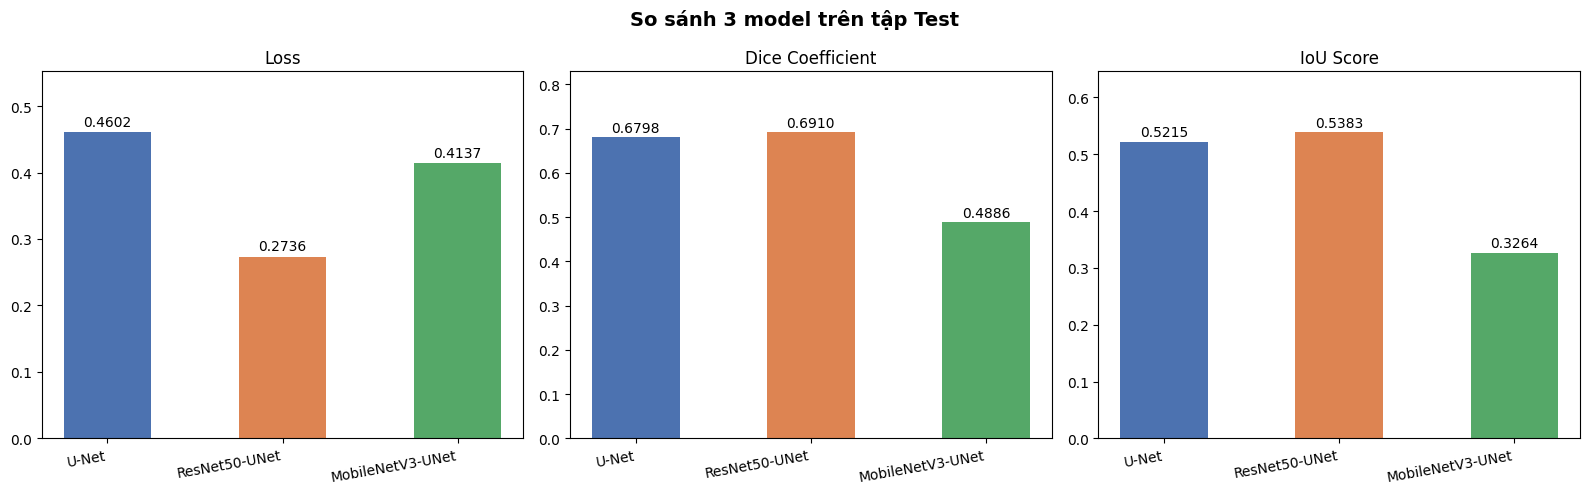

In [165]:
x = np.arange(len(model_names))
width = 0.25
colors = ["#4C72B0", "#DD8452", "#55A868"]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("So sánh 3 model trên tập Test", fontsize=14, fontweight="bold")

for ax, metric_idx, metric_title in zip(axes, [0, 1, 2], ["Loss", "Dice Coefficient", "IoU Score"]):
    vals = [res[metric_idx] for res in test_results]
    bars = ax.bar(x, vals, width=0.5, color=colors)
    ax.set_title(metric_title)
    ax.set_xticks(x)
    ax.set_xticklabels(model_names, rotation=10, ha="right")
    ax.set_ylim(0, max(vals) * 1.2)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f"{val:.4f}", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()

In [166]:
def merge_history(h1, h2=None):
    h1 = h1.history if hasattr(h1, "history") else h1
    if h2 is None:
        return h1
    h2 = h2.history if hasattr(h2, "history") else h2
    return {k: h1.get(k, []) + h2.get(k, []) for k in set(h1) | set(h2)}

hist_unet      = history_unet.history
hist_resnet    = merge_history(history_resnet, history_resnet_2)
hist_mobilenet = merge_history(history_mobilenet, history_mobilenet_2)

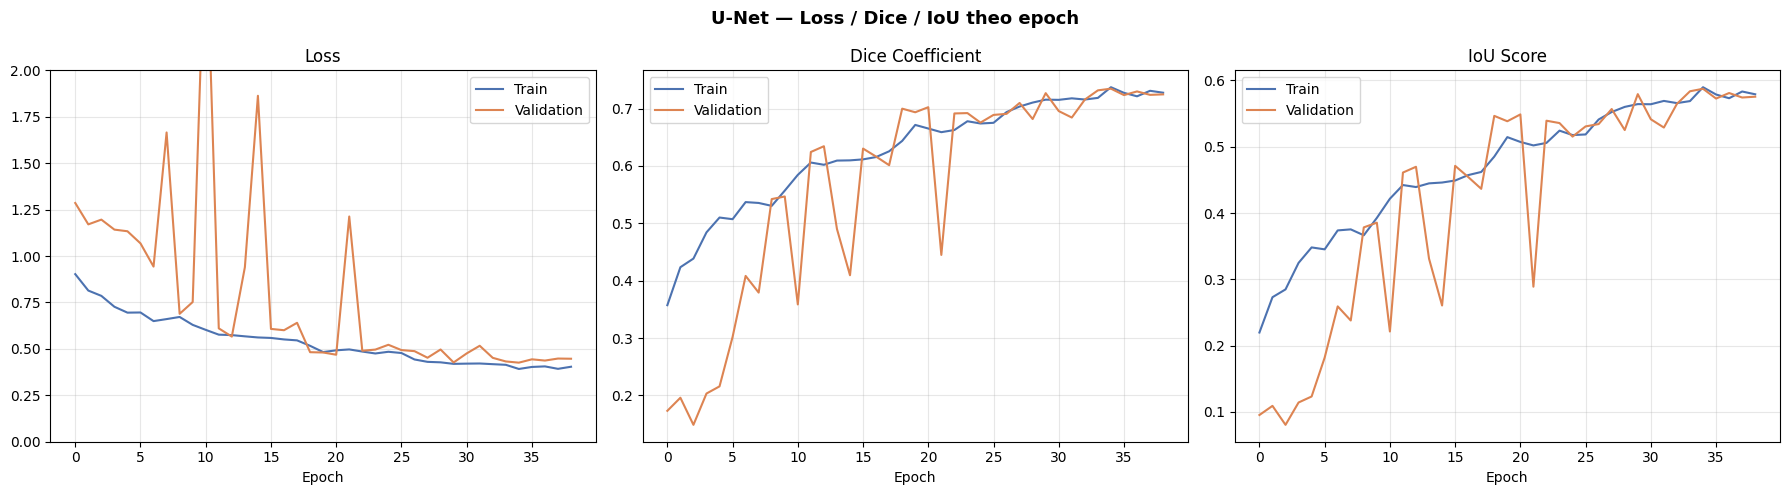

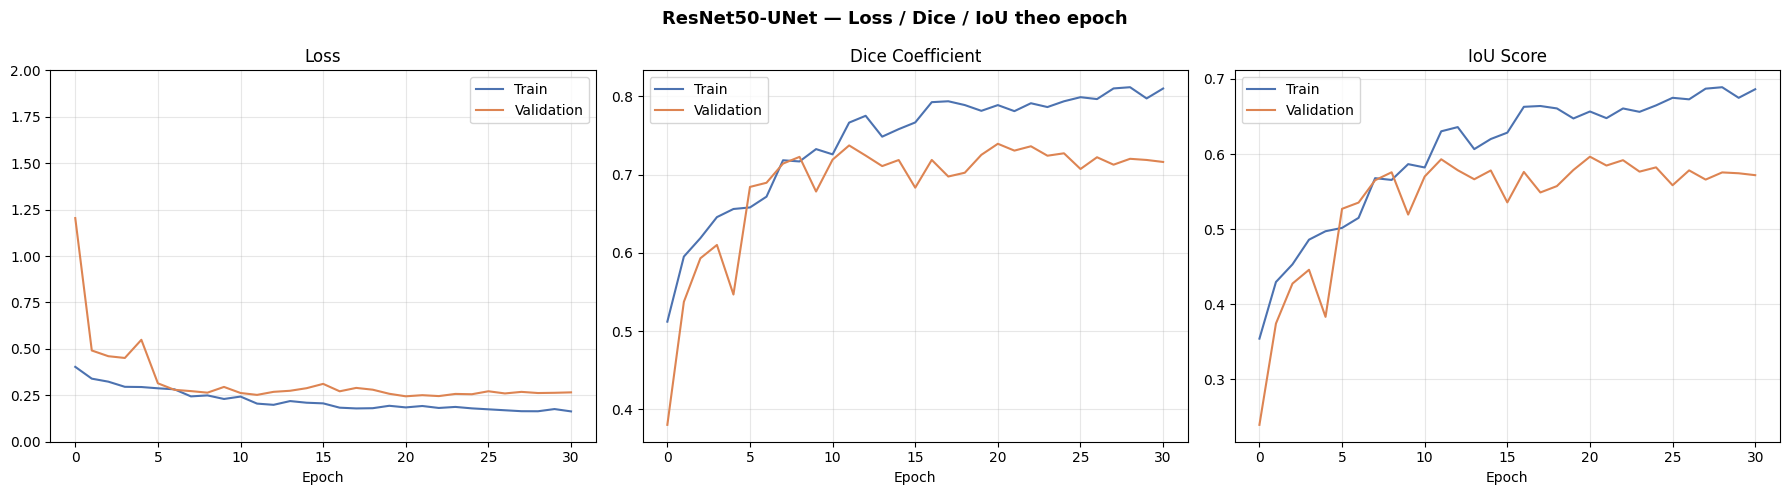

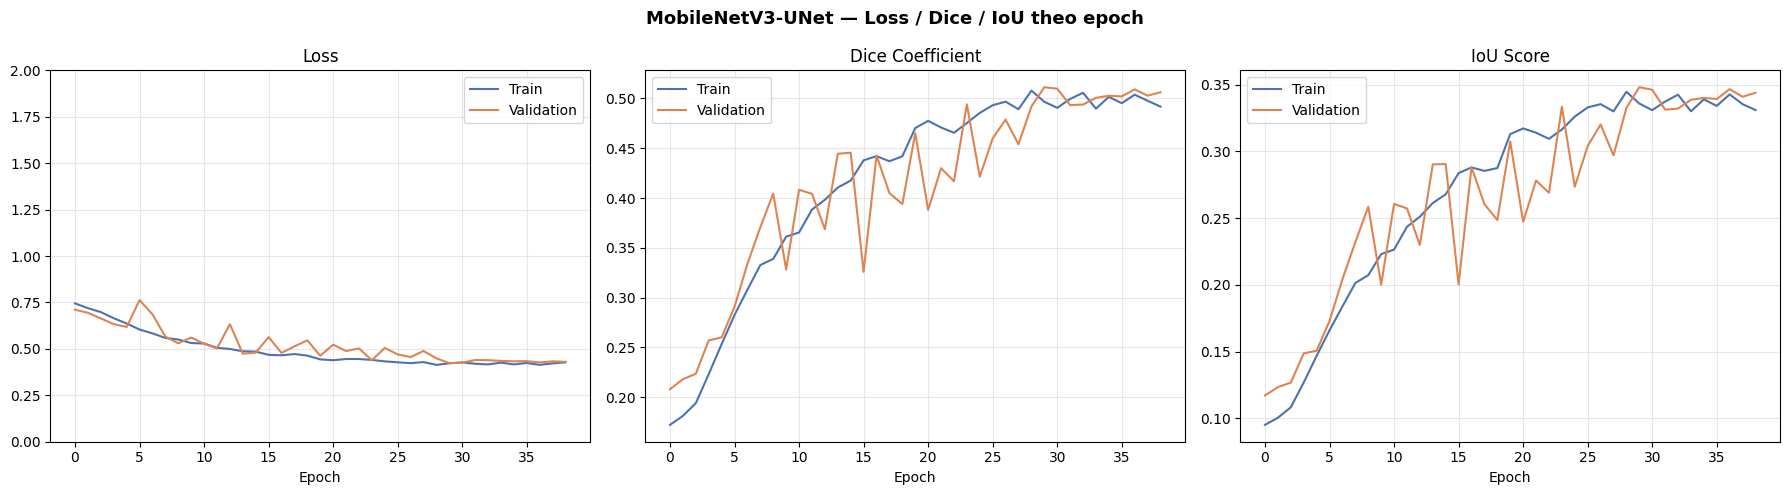

In [175]:
def plot_model_history(hist, model_name):
    metrics = ["loss", "dice_coefficient", "iou_score"]
    titles  = ["Loss", "Dice Coefficient", "IoU Score"]

    if hasattr(hist, "history"):
        hist = hist.history

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"{model_name} — Loss / Dice / IoU theo epoch",
                 fontsize=13, fontweight="bold")

    for ax, metric, title in zip(axes, metrics, titles):

        train = hist.get(metric, [])
        val   = hist.get(f"val_{metric}", [])

        if len(train) > 1:
            train = train[1:]
        if len(val) > 1:
            val = val[1:]

        if len(train) == 0 or len(val) == 0:
            print(f"[WARN] Không có dữ liệu cho {metric}")
            continue

        ax.plot(train, label="Train", color="#4C72B0")
        ax.plot(val,   label="Validation", color="#DD8452")

        ax.set_title(title)
        ax.set_xlabel("Epoch")
        ax.legend()
        ax.grid(alpha=0.3)

        if metric == "loss":
            ax.set_ylim(0, 2)

    plt.tight_layout()
    plt.show()

plot_model_history(hist_unet,      "U-Net")
plot_model_history(hist_resnet,    "ResNet50-UNet")
plot_model_history(hist_mobilenet, "MobileNetV3-UNet")

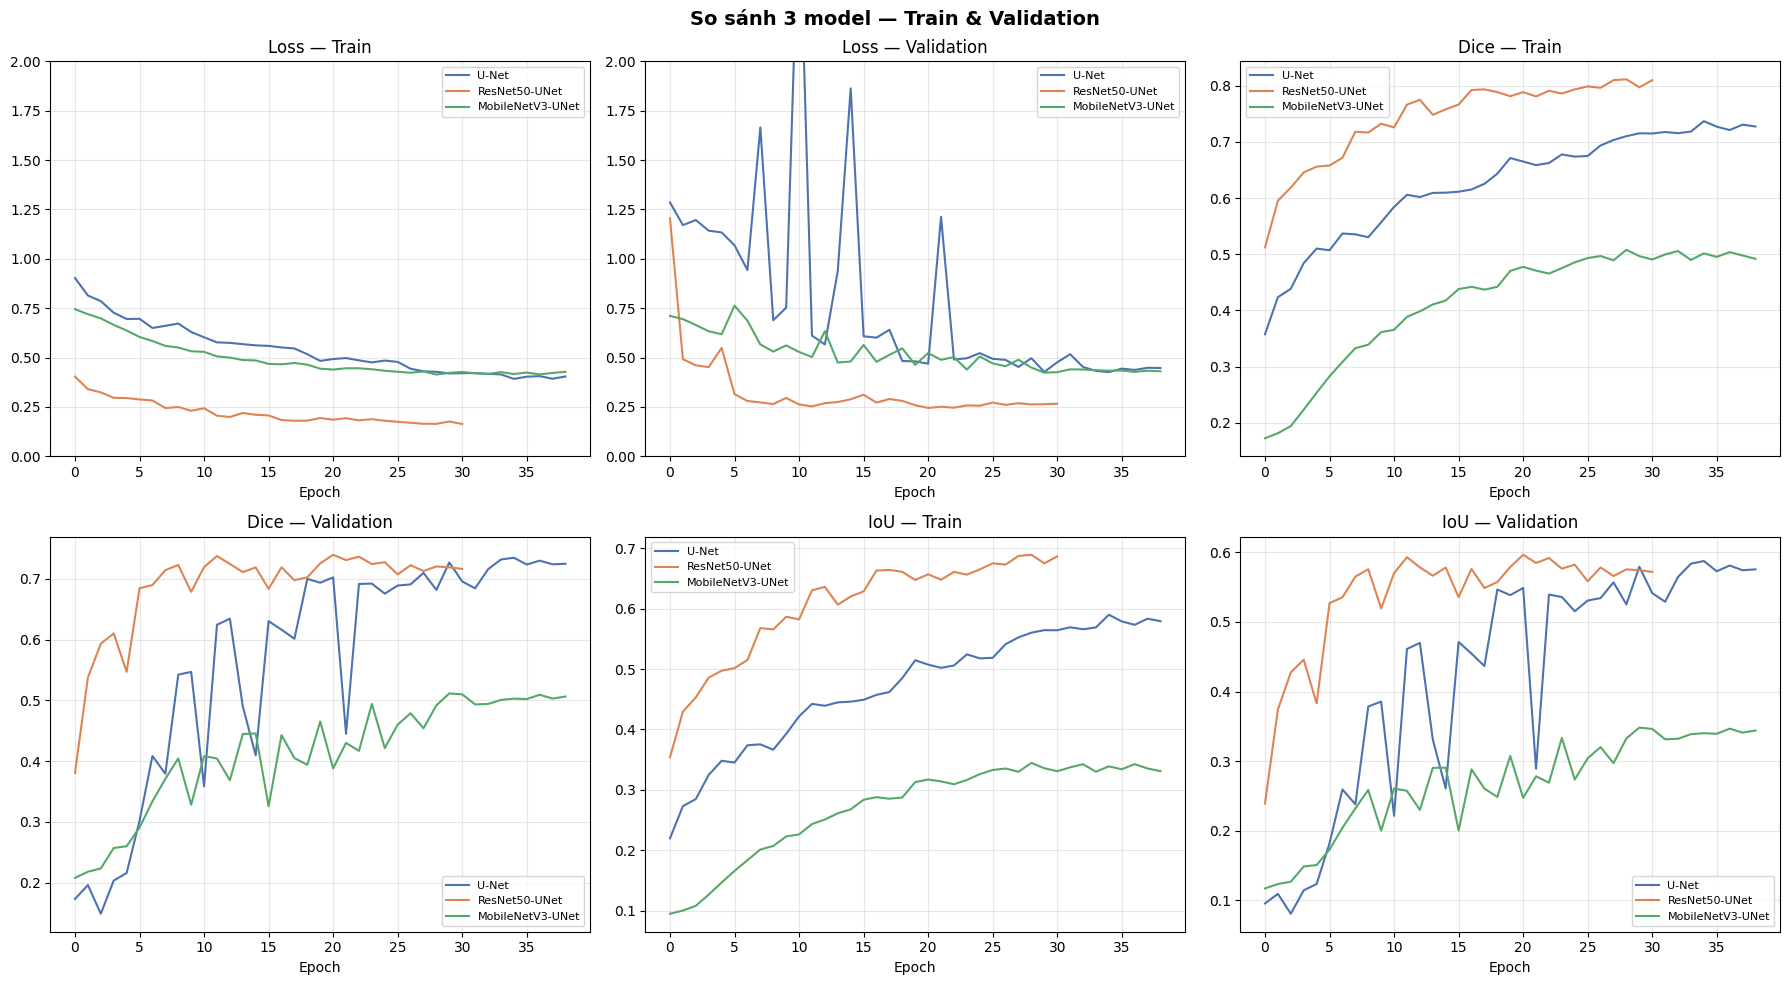

In [176]:
colors3 = {"U-Net": "#4C72B0", "ResNet50-UNet": "#DD8452", "MobileNetV3-UNet": "#55A868"}
hists3 = {"U-Net": hist_unet, "ResNet50-UNet": hist_resnet, "MobileNetV3-UNet": hist_mobilenet}
split_info = [
    ("loss", "train", "Loss — Train"),
    ("loss", "val", "Loss — Validation"),
    ("dice_coefficient","train","Dice — Train"),
    ("dice_coefficient","val", "Dice — Validation"),
    ("iou_score", "train", "IoU — Train"),
    ("iou_score", "val", "IoU — Validation"),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("So sánh 3 model — Train & Validation", fontsize=14, fontweight="bold")

for ax, (metric, split, title) in zip(axes.flatten(), split_info):
    key = metric if split == "train" else f"val_{metric}"
    for mname, hist in hists3.items():
        vals = hist[key]
        if len(vals) > 1:
            vals = vals[1:]
        ax.plot(vals, label=mname, color=colors3[mname])
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    if metric == "loss":
        ax.set_ylim(0, 2)


plt.tight_layout()
plt.show()

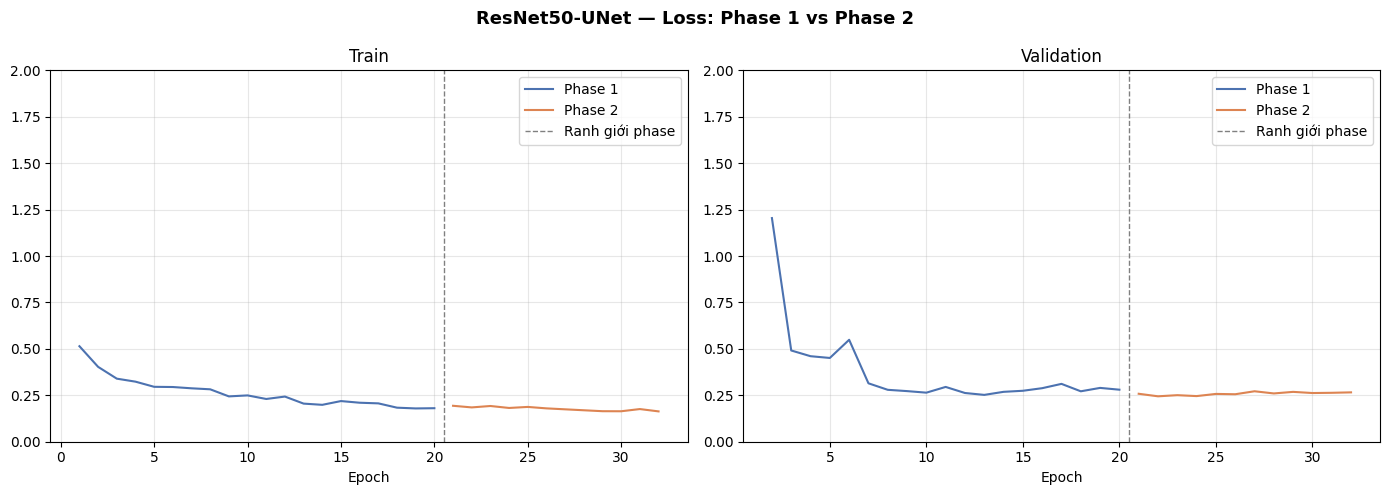

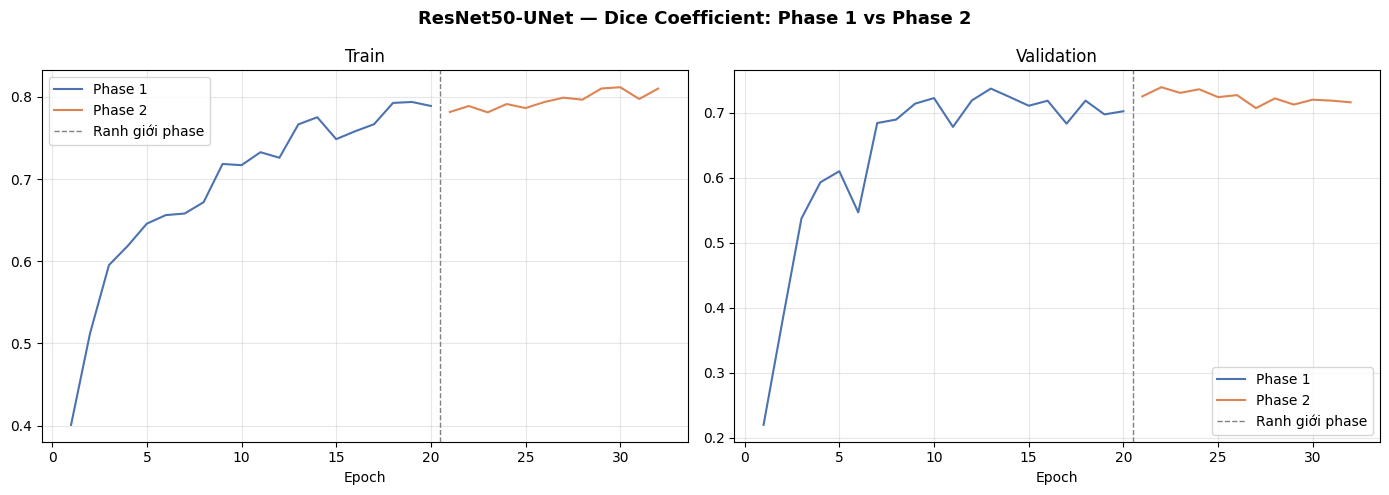

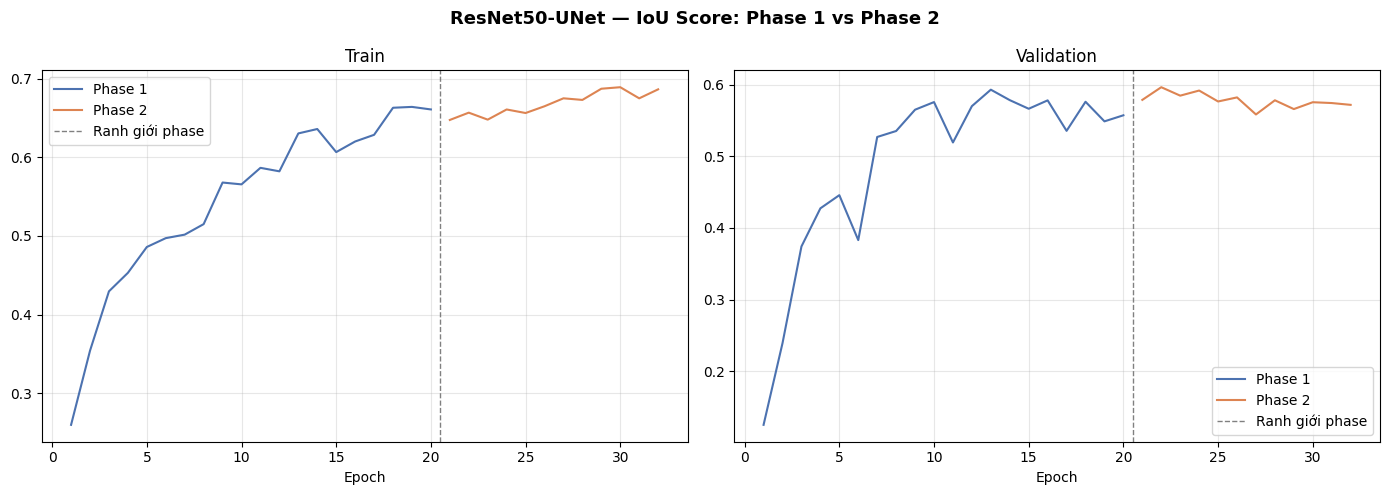

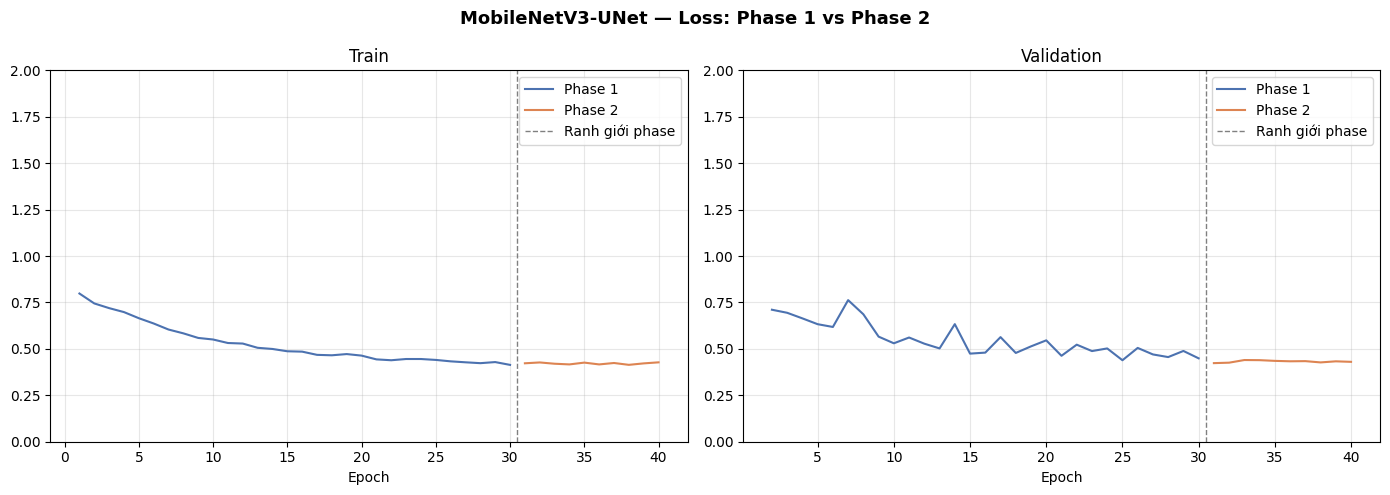

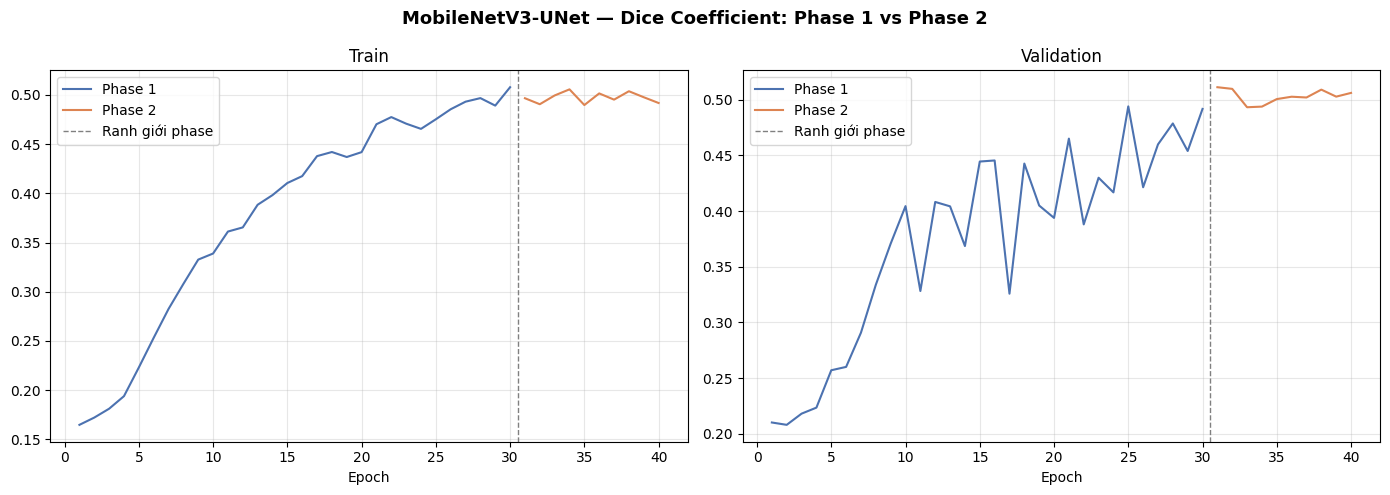

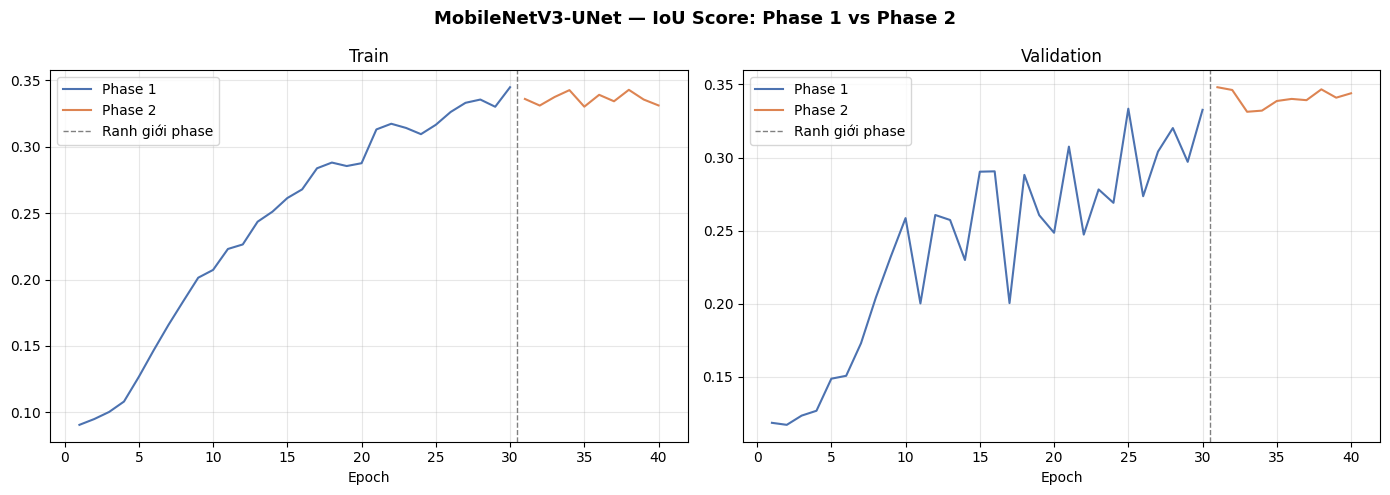

In [177]:
def plot_phases(hist_p1, hist_p2, model_name):
    merged = merge_history(hist_p1, hist_p2)
    n_p1   = len(hist_p1["loss"])
    metrics = ["loss", "dice_coefficient", "iou_score"]
    titles  = ["Loss", "Dice Coefficient", "IoU Score"]

    for metric, title in zip(metrics, titles):
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        fig.suptitle(f"{model_name} — {title}: Phase 1 vs Phase 2",
                     fontsize=13, fontweight="bold")

        for ax, split in zip(axes, ["Train", "Validation"]):
            key     = metric if split == "Train" else f"val_{metric}"
            vals    = merged[key]

            p1_vals  = vals[:n_p1]
            p2_vals  = vals[n_p1:]
            p1_range = range(1, n_p1 + 1)
            p2_range = range(n_p1 + 1, len(vals) + 1)

            if metric == "loss" and split == "Validation" and len(p1_vals) > 1:
                p1_vals  = p1_vals[1:]
                p1_range = range(2, n_p1 + 1)

            ax.plot(list(p1_range), p1_vals, color="#4C72B0", label="Phase 1")
            ax.plot(list(p2_range), p2_vals, color="#DD8452", label="Phase 2")
            ax.axvline(x=n_p1 + 0.5, color="gray", linestyle="--",
                       linewidth=1, label="Ranh giới phase")
            ax.set_title(split)
            ax.set_xlabel("Epoch")
            ax.legend()
            ax.grid(alpha=0.3)

            if metric == "loss":
                ax.set_ylim(0, 2)

        plt.tight_layout()
        plt.show()

plot_phases(history_resnet.history,    history_resnet_2.history,    "ResNet50-UNet")
plot_phases(history_mobilenet.history, history_mobilenet_2.history, "MobileNetV3-UNet")


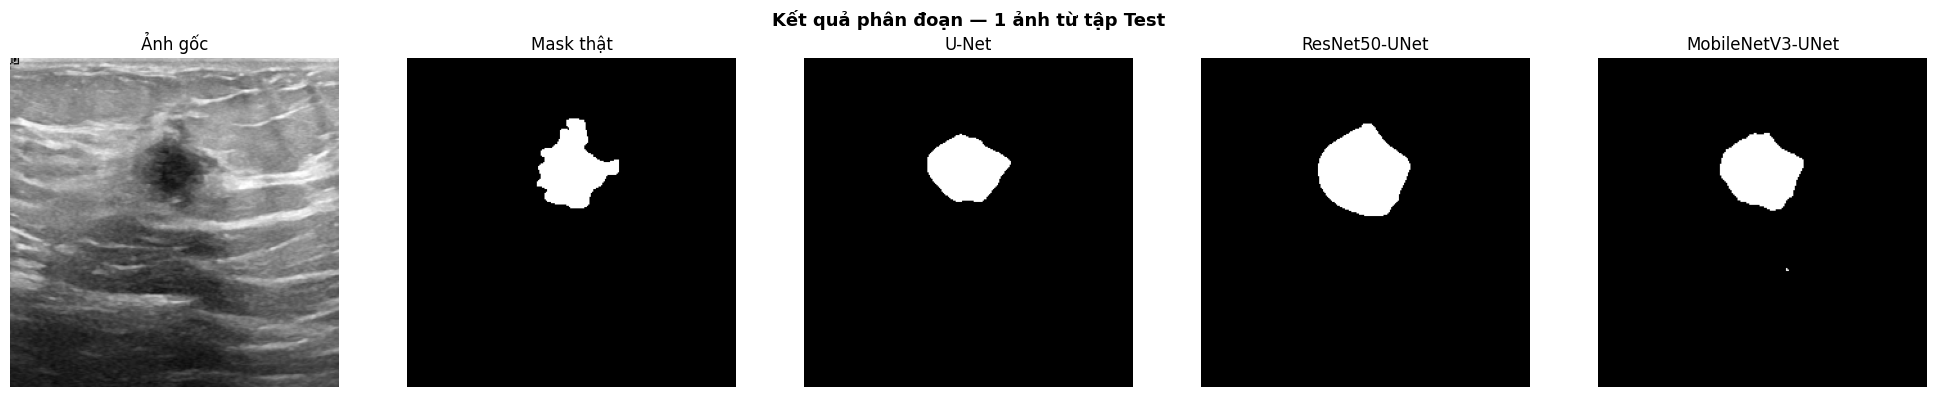

In [181]:
idx = 24  
pred_unet      = unet_model.predict(X_test_u[idx:idx+1],  verbose=0)
pred_resnet    = resnet_model.predict(X_test_r[idx:idx+1], verbose=0)
pred_mobilenet = mobilenet_model.predict(X_test_m[idx:idx+1], verbose=0)

def norm_display(img):
    return (img - img.min()) / (img.max() - img.min() + 1e-6)

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
fig.suptitle("Kết quả phân đoạn — 1 ảnh từ tập Test", fontsize=13, fontweight="bold")

axes[0].imshow(norm_display(X_test_u[idx]));                      axes[0].set_title("Ảnh gốc")
axes[1].imshow(y_test_u[idx, :, :, 0], cmap="gray");              axes[1].set_title("Mask thật")
axes[2].imshow(pred_unet[0, :, :, 0] > 0.5, cmap="gray");        axes[2].set_title("U-Net")
axes[3].imshow(pred_resnet[0, :, :, 0] > 0.5, cmap="gray");      axes[3].set_title("ResNet50-UNet")
axes[4].imshow(pred_mobilenet[0, :, :, 0] > 0.5, cmap="gray");   axes[4].set_title("MobileNetV3-UNet")

for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

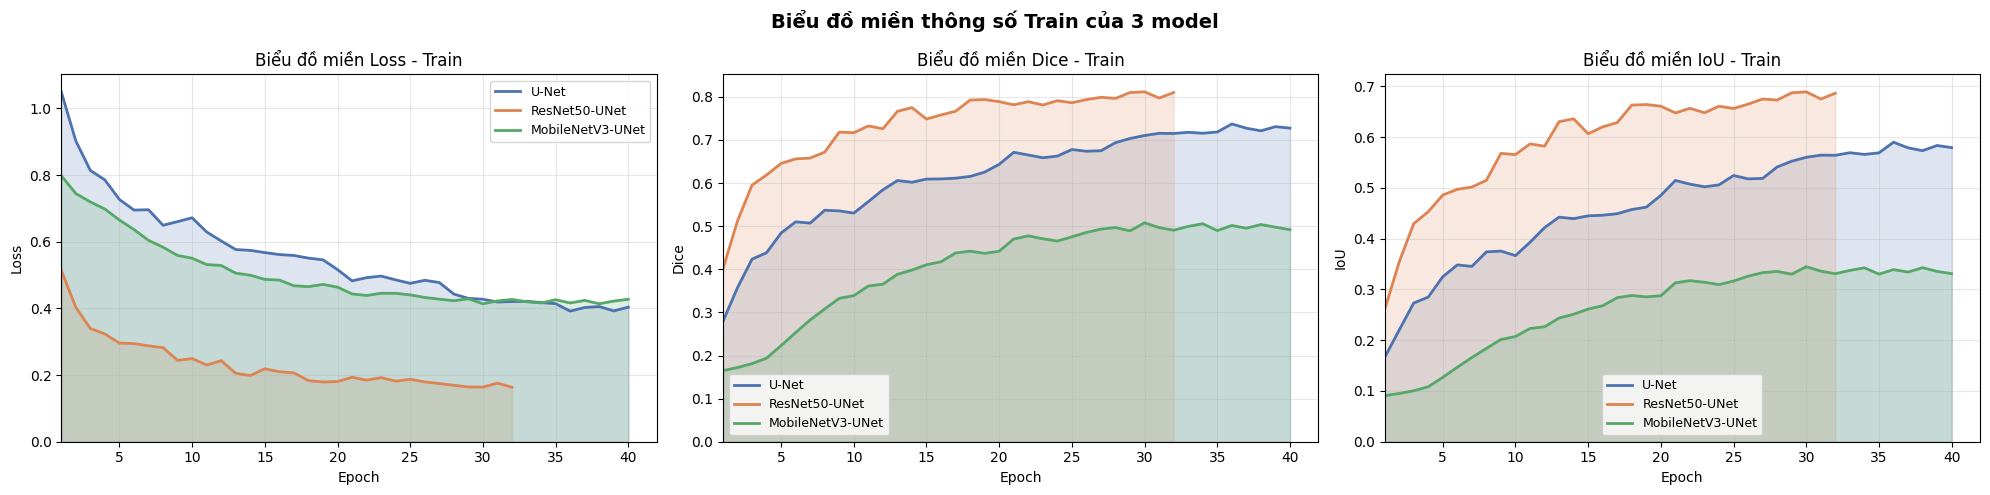

In [182]:
colors3 = {
    "U-Net": "#4C72B0",
    "ResNet50-UNet": "#DD8452",
    "MobileNetV3-UNet": "#55A868"
}

hists3 = {
    "U-Net": hist_unet,
    "ResNet50-UNet": hist_resnet,
    "MobileNetV3-UNet": hist_mobilenet
}

plot_info = [
    ("loss", "Biểu đồ miền Loss - Train", "Loss"),
    ("dice_coefficient", "Biểu đồ miền Dice - Train", "Dice"),
    ("iou_score", "Biểu đồ miền IoU - Train", "IoU"),
]

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle("Biểu đồ miền thông số Train của 3 model", fontsize=14, fontweight="bold")

for ax, (metric, title, ylabel) in zip(axes, plot_info):
    for model_name, hist in hists3.items():
        y = hist.get(metric, [])
        x = np.arange(1, len(y) + 1)

        ax.plot(x, y, color=colors3[model_name], linewidth=2, label=model_name)
        ax.fill_between(x, y, 0, color=colors3[model_name], alpha=0.18)

    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    ax.set_xlim(left=1)
    ax.set_ylim(bottom=0)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


In [172]:
import os
import json

SAVE_DIR = "/content/drive/MyDrive/saved_artifacts"
HIST_DIR = os.path.join(SAVE_DIR, "histories")
os.makedirs(HIST_DIR, exist_ok=True)

def save_json(obj, path):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2)

save_json(history_unet.history,        os.path.join(HIST_DIR, "history_unet.json"))
save_json(history_resnet.history,      os.path.join(HIST_DIR, "history_resnet_phase1.json"))
save_json(history_resnet_2.history,    os.path.join(HIST_DIR, "history_resnet_phase2.json"))
save_json(history_mobilenet.history,   os.path.join(HIST_DIR, "history_mobilenet_phase1.json"))
save_json(history_mobilenet_2.history, os.path.join(HIST_DIR, "history_mobilenet_phase2.json"))

def merge_history(h1, h2=None):
    h1 = h1.history if hasattr(h1, "history") else h1
    if h2 is None:
        return h1
    h2 = h2.history if hasattr(h2, "history") else h2
    return {k: h1.get(k, []) + h2.get(k, []) for k in set(h1) | set(h2)}

hist_resnet_full = merge_history(history_resnet.history, history_resnet_2.history)
hist_mobilenet_full = merge_history(history_mobilenet.history, history_mobilenet_2.history)

save_json(hist_resnet_full,    os.path.join(HIST_DIR, "history_resnet_full.json"))
save_json(hist_mobilenet_full, os.path.join(HIST_DIR, "history_mobilenet_full.json"))

print("Da luu history vao:", HIST_DIR)
print(os.listdir(HIST_DIR))


Da luu history vao: /content/drive/MyDrive/saved_artifacts/histories
['history_unet.json', 'history_mobilenet_full.json', 'history_resnet_phase2.json', 'history_resnet_phase1.json', 'history_resnet_full.json', 'history_mobilenet_phase1.json', 'history_mobilenet_phase2.json']


In [ ]:
import os
import json

SAVE_DIR = "/content/drive/MyDrive/saved_artifacts"
HIST_DIR = os.path.join(SAVE_DIR, "histories")

def load_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

hist_unet = load_json(os.path.join(HIST_DIR, "history_unet.json"))
hist_resnet = load_json(os.path.join(HIST_DIR, "history_resnet_full.json"))
hist_mobilenet = load_json(os.path.join(HIST_DIR, "history_mobilenet_full.json"))

print("Da load xong history.")
print(hist_unet.keys())
print(hist_resnet.keys())
print(hist_mobilenet.keys())


In [173]:
test_summary = {
    "U-Net": {
        "loss": float(res_unet[0]),
        "dice": float(res_unet[1]),
        "iou": float(res_unet[2]),
    },
    "ResNet50-UNet": {
        "loss": float(res_resnet[0]),
        "dice": float(res_resnet[1]),
        "iou": float(res_resnet[2]),
    },
    "MobileNetV3-UNet": {
        "loss": float(res_mobilenet[0]),
        "dice": float(res_mobilenet[1]),
        "iou": float(res_mobilenet[2]),
    },
}

with open(os.path.join(SAVE_DIR, "test_summary.json"), "w", encoding="utf-8") as f:
    json.dump(test_summary, f, indent=2)


In [ ]:
with open(os.path.join(SAVE_DIR, "test_summary.json"), "r", encoding="utf-8") as f:
    test_summary = json.load(f)

print(test_summary)


In [174]:
import os
import json
import shutil

BASE_DIR = "/content/drive/MyDrive/saved_artifacts"
HIST_DIR = os.path.join(BASE_DIR, "histories")
MODEL_DIR = os.path.join(BASE_DIR, "models")
os.makedirs(HIST_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

def save_json(obj, path):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2)

def merge_history(h1, h2=None):
    h1 = h1.history if hasattr(h1, "history") else h1
    if h2 is None:
        return h1
    h2 = h2.history if hasattr(h2, "history") else h2
    return {k: h1.get(k, []) + h2.get(k, []) for k in set(h1) | set(h2)}

hist_unet = history_unet.history
hist_resnet = merge_history(history_resnet, history_resnet_2)
hist_mobilenet = merge_history(history_mobilenet, history_mobilenet_2)

save_json(hist_unet,      os.path.join(HIST_DIR, "history_unet.json"))
save_json(hist_resnet,    os.path.join(HIST_DIR, "history_resnet_full.json"))
save_json(hist_mobilenet, os.path.join(HIST_DIR, "history_mobilenet_full.json"))

test_summary = {
    "U-Net": {
        "loss": float(res_unet[0]),
        "dice": float(res_unet[1]),
        "iou": float(res_unet[2]),
    },
    "ResNet50-UNet": {
        "loss": float(res_resnet[0]),
        "dice": float(res_resnet[1]),
        "iou": float(res_resnet[2]),
    },
    "MobileNetV3-UNet": {
        "loss": float(res_mobilenet[0]),
        "dice": float(res_mobilenet[1]),
        "iou": float(res_mobilenet[2]),
    },
}
save_json(test_summary, os.path.join(BASE_DIR, "test_summary.json"))

checkpoint_map = {
    "unet_best.keras": "/kaggle/working/unet_best.keras",
    "resnet_phase1_best.keras": "/kaggle/working/resnet_phase1_best.keras",
    "resnet_phase2_best.keras": "/kaggle/working/resnet_phase2_best.keras",
    "mobilenet_phase1_best.keras": "/kaggle/working/mobilenet_phase1_best.keras",
    "mobilenet_phase2_best.keras": "/kaggle/working/mobilenet_phase2_best.keras",
}

for dst_name, src_path in checkpoint_map.items():
    if os.path.exists(src_path):
        shutil.copy2(src_path, os.path.join(MODEL_DIR, dst_name))
        print("Da luu:", dst_name)
    else:
        print("Khong tim thay:", src_path)

print("Hoan tat luu du lieu vao:", BASE_DIR)
print("Histories:", os.listdir(HIST_DIR))
print("Models:", os.listdir(MODEL_DIR))


Da luu: unet_best.keras
Da luu: resnet_phase1_best.keras
Da luu: resnet_phase2_best.keras
Da luu: mobilenet_phase1_best.keras
Da luu: mobilenet_phase2_best.keras
Hoan tat luu du lieu vao: /content/drive/MyDrive/saved_artifacts
Histories: ['history_unet.json', 'history_mobilenet_full.json', 'history_resnet_phase2.json', 'history_resnet_phase1.json', 'history_resnet_full.json', 'history_mobilenet_phase1.json', 'history_mobilenet_phase2.json']
Models: ['mobilenet_phase2_best.keras', 'resnet_phase2_best.keras', 'mobilenet_phase1_best.keras', 'resnet_phase1_best.keras', 'unet_best.keras']
